# 2.2. Modelos Lineales

## Setup

In [3]:
# Módulos
import os
import session_info

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn import set_config
from sklearn import datasets
from sklearn.linear_model import Lars, LarsCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate

import warnings

set_config(transform_output="pandas")
sns.set_style('dark')
pio.templates.default = "plotly_dark"
warnings.filterwarnings("ignore")

%matplotlib inline

dir_data = '../03_Data/'

In [5]:
session_info.show()

In [6]:
# Funciones
def color_negative_red(val,value):
    if val == 1:
        color = 'grey'
    elif np.abs(val) > value:
        color = 'red'
    else:
        color = 'white'
    return f'color: {color}'

def get_style(data, fun, **kw):
    styled_data = data.style.applymap(fun, **kw)
    styled_data.to_html('styled_data.html', escape=False)
    return styled_data

def get_cv_scores_report(estimator, X, y, n_splits):
    cv_scores = cross_validate(
                    estimator = estimator,
                    X         = X,
                    y         = y,
                    scoring   = ('r2', 'neg_root_mean_squared_error','neg_mean_absolute_percentage_error'),
                    cv        = RepeatedKFold(n_splits=n_splits, n_repeats=5, random_state=333),
                )


    # Se convierte el diccionario a dataframe para facilitar la visualización
    cv_scores = pd.DataFrame(cv_scores)
    print(f"R2 en CV: mean {cv_scores.test_r2.mean():.2f}, std {cv_scores.test_r2.std():.2f}")
    print(f"RMSE en CV: mean {-cv_scores.test_neg_root_mean_squared_error.median():.2f}, std {cv_scores.test_neg_root_mean_squared_error.std():.2f}")
    print(f"MAPE en CV: mean {-cv_scores.test_neg_mean_absolute_percentage_error.median():.2f}, std {cv_scores.test_neg_mean_absolute_percentage_error.std():.2f}")

## 2.2.2. Regresión LARS (Least Angle Regression Stepwise)

### 2.2.2.1 Procedimiento

Los modelos lineales tradicionales son altamente funcionales para la mayoría de los problemas que se afrontan en cuanto a inferencia y predicción, sin ambargo, cuando existe alta dimensionalidad o una simple invalidación de las premisas de nuestros modelos clásicos, estos pueden verse altamente afectados o simplemente es imposible de generarlos.

Es por ello que a lo largo del tiempo, se han desarrollado nuevos métodos y modelos para poder atacar estos problemas. Entre ellos tenemos la regresión **LARS**.

Recordemos el algoritmo de **LARS**:

 - Para $X_1 , ..., X_p$ se estandarizan de tal manera que $\forall_{i=1,\ldots,p} \quad \mu_i = 0 \quad \text{y} \quad \sigma_i^2 = 1
$
 - Iniciar con el modelo sin regresores o $\forall_{i=1,\ldots,p}$ $\beta_i=0$ y calcular los residuales del modelo (*i.e.* $r = y - \hat{y}$)
 - Obtener las correlaciones entre las características y el vector residual $c_j = X_j^T r$  $\forall_{i=1,\ldots,p}$.
 - Obtener las correlaciones $j$ (llamada entonces característica activa) con máxima correlacion absoluta $|c_j|$ y agregarla al modelo.
 - Mover $\beta_j$ hacia dirección $c_j$ hasta que alguna de las características no activas $X_k$ alcance un coeficiente igual a ella en magnitud. Entonces se agrega $X_k$ y se calcula $c_k$.
 - Mover ahora $\beta_j$ y $\beta_k$ de forma paralela en dirección de $c_j,c_k$, hasta encontrar una nueva variable activa que contenga tanta correlación con el nuevo residual del modelo generado.
 - Realizar iterativamente este proceso hasta que: se ingresen las $p$ características, un número máximo de ellas se ingresen (previamente definido) o exista una convergencia en el ajuste del modelo.

**Realicemos un mini-ejercicio:**

In [7]:
# Definiendo las variables ficticias
X = pd.DataFrame(np.array([[1, 2, 300], [2, -4, 100], [3, 5, 1], [4, -8, 200]]),columns=['X1','X2','X3'])  # 4 observaciones, 3 variables
y = np.array([4, 8, 6, 10])  # Variable dependiente

X = StandardScaler().fit_transform(X)
X

,X1,X2,X3
0,-1.341641,0.641243,1.343431
1,-0.447214,-0.542590,-0.450801
2,0.447214,1.233159,-1.338945
3,1.341641,-1.331812,0.446315


**Paso 1: Escoger el primer predictor**

In [87]:
correlations = np.corrcoef(X, rowvar=False, y=y)[:3, 3]  # Correlaciones de cada variable con Y
initial_predictor_index = np.argmax(np.abs(correlations))  # Escogemos el predictor con la correlación más alta
correlations

array([ 0.8       , -0.86031737, -0.20160421])

In [88]:
X.values[:, [initial_predictor_index]]

array([[ 0.64124271],
       [-0.54258999],
       [ 1.23315906],
       [-1.33181178]])

**Paso 2: Mover el primer predictor hacia su coeficiente de regresión de mínimos cuadrados**

In [89]:
model = LinearRegression().fit(X.values[:, [initial_predictor_index]], y)
y_pred = model.predict(X.values[:, [initial_predictor_index]])
residuos = y - y_pred
residuos

array([-1.76642336, -0.04379562,  1.37226277,  0.4379562 ])

**Paso 3: Escoger el segundo predictor y mover en dirección equiangular**

In [91]:
correlations = np.corrcoef(X, rowvar=False, y=residuos)[:3, 3]

# Ponemos a cero la correlación del predictor ya seleccionado para no volverlo a seleccionar.
correlations[initial_predictor_index] = 0

# Escogemos el predictor con la correlación más alta con los residuos.
second_predictor_index = np.argmax(np.abs(correlations))
correlations

array([ 0.78754868,  0.        , -0.87626105])

In [93]:
# Concatenamos los índices de los predictores seleccionados
selected_predictors = [initial_predictor_index, second_predictor_index]

# Ajustamos el modelo y calculamos los residuos
model = LinearRegression().fit(X.values[:, selected_predictors], Y)
y_pred = model.predict(X.values[:, selected_predictors])
residuos = y - y_pred
residuos

array([1.56279109, 0.14599737, 0.2144692 , 2.07674234])

**Paso 4: Continuar el proceso o detenerlo**

In [95]:
# Aquí, simplemente continuamos el proceso con el tercer predictor
third_predictor_index = 3 - initial_predictor_index - second_predictor_index  # El que no ha sido seleccionado aún
selected_predictors = [initial_predictor_index, second_predictor_index, third_predictor_index]

# Ajustamos el modelo con los tres predictores
model = LinearRegression().fit(X.values[:, selected_predictors], Y)
y_pred = model.predict(X.values[:, selected_predictors])
residuos = y - y_pred
residuos

array([ 2.,  3., -1.,  0.])

### 2.2.2.2 Ejemplo

Para comprender LARS y hacer honor a sus creadores utilizaremos la TAD que utilizaron para presentar *LARS*, el conjunto de datos se llamada **Diabetes**, donde se obtuvieron diez variables iniciales: edad, sexo, índice de masa corporal, presión arterial promedio y seis mediciones de suero sanguíneo para cada uno de los n = 442 pacientes con diabetes, además de la respuesta de interés la cuál es una medida cuantitativa de la progresión de la enfermedad un año después del inicio.

**Nota**: Cada una de estas 10 variables de características ha sido centrada en la media y escalada por la desviación estándar multiplicada por la raíz cuadrada del número de muestras (es decir, la suma de los cuadrados de cada columna totaliza 1).

Para más información consultar el siguiente [Link](https://web.stanford.edu/~hastie/Papers/LARS/LeastAngle_2002.pdf).

In [9]:
db = datasets.load_diabetes()
X = pd.DataFrame(db['data'],columns=db['feature_names'])
y = pd.DataFrame(db['target'],columns=['qmdp'])

Observamos que tenemos variables altamente correlacionadas con otras:

En este caso se muestran correlaciones superiores a 0.3 marcadas en <span style="color:red">rojo</span>.

In [11]:
get_style(X.corr(), color_negative_red, value=0.3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


In [12]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    train_size=0.3,
                                                    random_state=333,
                                                    shuffle=True)

In [13]:
la = Lars(n_nonzero_coefs=3).fit(X_train, y_train)
print(la.score(X_train,y_train))

0.40356637043112176


In [140]:
pd.DataFrame(la.coef_,index=X.columns,columns=['Coeficientes Seleccionados 3'])

,Coeficientes Seleccionados 3
age,0.000000
sex,0.000000
bmi,336.621223
bp,0.000000
s1,0.000000
s2,0.000000
s3,-9.053014
s4,0.000000
s5,432.318434
s6,0.000000


Realizamos un proceso iterativo para observar el rendimiento en el entrenamiento según el número de variables para LARS:

In [141]:
for x  in np.arange(1,X.shape[1] + 1):
    # Modelación
    la = Lars(n_nonzero_coefs=x).fit(X_train, y_train)
    print('Número de coeficientes:',x,':', la.score(X_train,y_train))

Número de coeficientes: 1 : 0.05126307739201286
Número de coeficientes: 2 : 0.3956640581497409
Número de coeficientes: 3 : 0.40356637043112176
Número de coeficientes: 4 : 0.44890882221438744
Número de coeficientes: 5 : 0.4844470755210766
Número de coeficientes: 6 : 0.523637859479892
Número de coeficientes: 7 : 0.5662359284920722
Número de coeficientes: 8 : 0.5621582938034971
Número de coeficientes: 9 : 0.5527878189831079
Número de coeficientes: 10 : 0.5395552383080832


Cómo este proceso puede ser tardado e inestable ya que no se ha realizado crossvalidación, existe una optimización de este modelo:

In [17]:
# Inicializar y ajustar LarsCV
la10 = LarsCV(cv=10)
la10.fit(X_train, y_train)

display(pd.DataFrame(la10.coef_,index=X.columns,columns=['Coeficientes Seleccionados']))
print("Intercepto:", la10.intercept_)

,Coeficientes Seleccionados
age,0.000000
sex,-222.717323
bmi,476.861892
bp,221.701295
s1,-769.981723
s2,445.862954
s3,94.262459
s4,0.000000
s5,886.807143
s6,0.000000


Intercepto: 151.94891015600845


<details>
<summary>¿Qué notamos? </summary>

Al utilizar la optimización a una cross validación adecuada logramos precisamente que el número de características que eligimos utilizando el criterio de R2 coincidiera con el de `LarsCV`.

El secreto esta en el número de CV, y esto dependerá del tamaño de conjunto de datos.

Entonces pues, si comparamos los coeficientes de regresión lineal con respecto a LARS vemos que:

In [18]:
# Inicializar y ajustar LarsCV
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [19]:
# Crear un DataFrame con los coeficientes de ambos modelos
coef_df = pd.DataFrame({'Linear Regresion': lr.coef_.flatten(),
                        'LARS (CV: 10)': la10.coef_.flatten()}, index=X.columns)

# Calcular el porcentaje de variación entre los coeficientes
coef_df['Porcentaje Variación'] = np.round(((coef_df['Linear Regresion'] - coef_df['LARS (CV: 10)']) / coef_df['LARS (CV: 10)']) * 100,2)\
                                 .replace(-np.inf, ' ').replace(np.inf, ' ')

coef_df

,Linear Regresion,LARS (CV: 10),Porcentaje Variación
age,-50.736585,0.000000,
sex,-277.141419,-222.717323,24.44
bmi,538.001321,476.861892,12.82
bp,320.314093,221.701295,44.48
s1,-1333.963449,-769.981723,73.25
s2,848.753108,445.862954,90.36
s3,284.452414,94.262459,201.77
s4,28.798924,0.000000,
s5,1155.896681,886.807143,30.34
s6,-98.683838,0.000000,


Pongamos a prueba nuestro modelo:

In [20]:
get_cv_scores_report(la10,X_test,y_test,5)

R2 en CV: mean 0.46, std 0.07
RMSE en CV: mean 57.76, std 3.96
MAPE en CV: mean 0.40, std 0.08


In [154]:
y.describe()

,qmdp
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


<details>
<summary>¿Qué puede mejorar? </summary>

Ingresar más características de valor, sin embargo, en general es un buen modelo ya que comparando el RMSE la variación no es demasiada con respecto al promedio.

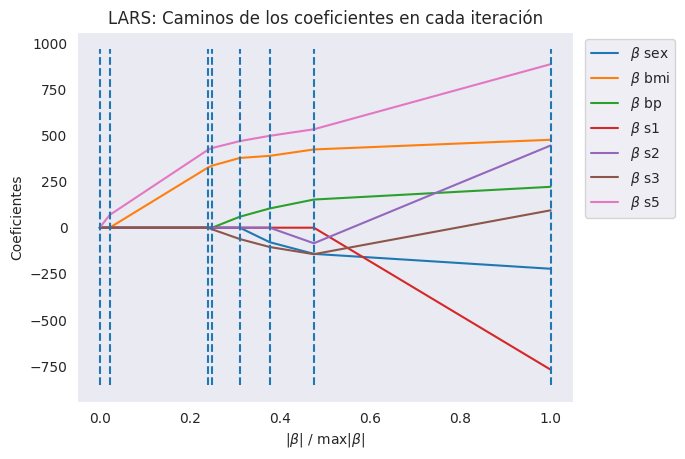

In [163]:
coefs = la10.coef_path_
xx = np.sum(np.abs(coefs.T), axis=1)
xx /= xx[-1]
coef_labels = []
for i, coef in enumerate(coefs):
    if np.any(coef != 0):
        plt.plot(xx, coef, label=f"$\\beta$ {X.columns[i]}")  # Agregar el nombre de la característica a la etiqueta
        coef_labels.append(X.columns[i])  # Agregar el nombre del coeficiente no cero a la lista


ymin, ymax = plt.ylim()
plt.vlines(xx, ymin, ymax, linestyle="dashed")
plt.xlabel("|$\\beta$| / max|$\\beta$|")
plt.ylabel("Coeficientes")
plt.title("LARS: Caminos de los coeficientes en cada iteración")
plt.axis("tight")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

In [164]:
pd.to_pickle(la10,'./01_Models/model_lacv.pkl')